# Knowledge Graph Construction with Claude

A knowledge graph is a structured representation of facts: **entities** (people, organizations, places, events) connected by **typed relations** (works-for, located-in, part-of). Search engines use them to answer "who founded X" without reading a single document. RAG systems use them to reason across facts that never appear together in one chunk.

Building one used to mean training a named-entity recognizer on your domain, training a relation classifier, writing entity-resolution heuristics, and maintaining all three as your data shifted. With Claude, each of those stages becomes a prompt.

This guide walks through the full classical pipeline:

1. **Named entity recognition + relation extraction** — pull typed entities and subject–predicate–object triples from raw text
2. **Entity resolution** — collapse "NASA", "National Aeronautics and Space Administration", and "the space agency" into one node
3. **Graph assembly** — load the cleaned triples into NetworkX and visualize the result
4. **Entity summarization** — generate rich profiles for each node by pooling every mention across the corpus
5. **Graph querying** — answer multi-hop questions by handing Claude a serialized subgraph

Everything runs in memory with no database. The techniques transfer directly to Neo4j, Neptune, or a Postgres adjacency table when you need to scale.

## Prerequisites
- Python 3.11+
- Anthropic API key ([get one here](https://console.anthropic.com))
- Basic familiarity with graphs (nodes, edges, traversal)

## Setup

In [1]:
%pip install anthropic wikipedia networkx matplotlib --quiet

/Users/montana/code/claude-cookbooks/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from collections import defaultdict

import anthropic
import matplotlib.pyplot as plt
import networkx as nx
import wikipedia

client = anthropic.Anthropic()

EXTRACTION_MODEL = "claude-haiku-4-5"
SYNTHESIS_MODEL = "claude-sonnet-4-6"

We use two models. Haiku handles the high-volume, schema-constrained extraction work where speed and cost matter more than nuance. Sonnet handles entity resolution and summarization, where the model needs to weigh conflicting evidence across documents.

## Building a corpus

We need a handful of documents that talk about overlapping entities, so that entity resolution has real work to do. The Apollo program is a good test bed: six short Wikipedia summaries that all mention NASA, the Moon, several astronauts, and a launch vehicle — but each article names them slightly differently.

We fetch summaries rather than full articles to keep token costs low. For a production pipeline you would chunk full documents; the extraction logic is identical.

In [3]:
ARTICLE_TITLES = [
    "Apollo program",
    "Apollo 11",
    "Neil Armstrong",
    "Saturn V",
    "Buzz Aldrin",
    "Kennedy Space Center",
]

documents = []
for i, title in enumerate(ARTICLE_TITLES):
    try:
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False)
        documents.append({"id": i, "title": title, "text": summary})
    except wikipedia.exceptions.WikipediaException as e:
        print(f"Skipping {title}: {e}")

print(f"Loaded {len(documents)} documents\n")
print(f"Sample — {documents[0]['title']}:\n{documents[0]['text'][:300]}...")

Loaded 6 documents

Sample — Apollo program:
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led by NASA, which landed the first humans on the Moon in 1969. Apollo was conceived during Project Mercury and executed after Project Gemini. It was conceived in 1960 as a three-person spacecraft durin...


## Entity and relation extraction

Classical NER tags spans of text with labels (PERSON, ORG, LOC). Classical relation extraction then classifies pairs of spans into relation types. Both traditionally require labeled training data per domain.

We collapse both stages into a single Claude call per document. The key is **forced tool use**: by setting `tool_choice` to a specific tool name, we guarantee the response is a well-formed JSON object matching our schema. No regex parsing, no malformed output recovery.

In [4]:
ENTITY_TYPES = ["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]

extract_tool = {
    "name": "extract_graph",
    "description": "Record the entities and relations found in a document.",
    "input_schema": {
        "type": "object",
        "properties": {
            "entities": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The entity's name exactly as it appears or is most commonly referred to in this document.",
                        },
                        "type": {"type": "string", "enum": ENTITY_TYPES},
                        "description": {
                            "type": "string",
                            "description": "One sentence grounded in this document. Used later to disambiguate entities with similar names.",
                        },
                    },
                    "required": ["name", "type", "description"],
                },
            },
            "relations": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "source": {
                            "type": "string",
                            "description": "Name of the source entity (must appear in entities above).",
                        },
                        "predicate": {
                            "type": "string",
                            "description": "Short verb phrase: 'commanded', 'launched from', 'part of'.",
                        },
                        "target": {
                            "type": "string",
                            "description": "Name of the target entity (must appear in entities above).",
                        },
                    },
                    "required": ["source", "predicate", "target"],
                },
            },
        },
        "required": ["entities", "relations"],
    },
}

EXTRACTION_PROMPT = """Extract a knowledge graph from the document below.

<document>
{text}
</document>

Extract only entities that are central to what this document is about — skip incidental mentions. Every relation must connect two entities you extracted."""


def extract(text: str) -> dict:
    response = client.messages.create(
        model=EXTRACTION_MODEL,
        max_tokens=2048,
        tools=[extract_tool],
        tool_choice={"type": "tool", "name": "extract_graph"},
        messages=[{"role": "user", "content": EXTRACTION_PROMPT.format(text=text)}],
    )
    return next(b.input for b in response.content if b.type == "tool_use")

In [5]:
raw_entities = []
raw_relations = []

for doc in documents:
    result = extract(doc["text"])
    for ent in result["entities"]:
        ent["source_doc"] = doc["title"]
        raw_entities.append(ent)
    for rel in result["relations"]:
        rel["source_doc"] = doc["title"]
        raw_relations.append(rel)
    print(
        f"{doc['title']:<25} {len(result['entities']):>3} entities  {len(result['relations']):>3} relations"
    )

print(f"\nTotal: {len(raw_entities)} raw entities, {len(raw_relations)} raw relations")

Apollo program             12 entities    9 relations


Apollo 11                  15 entities   15 relations


Neil Armstrong              9 entities    8 relations


Saturn V                   10 entities    9 relations


Buzz Aldrin                 8 entities    8 relations


Kennedy Space Center        9 entities    8 relations

Total: 63 raw entities, 57 raw relations


Let's look at what was extracted. Notice how the same real-world entity appears under different surface forms across documents — this is the entity resolution problem we solve next.

In [6]:
by_type = defaultdict(list)
for e in raw_entities:
    by_type[e["type"]].append(e["name"])

for etype, names in sorted(by_type.items()):
    print(f"{etype} ({len(names)}):")
    for name in sorted(set(names)):
        print(f"  {name}")
    print()

ARTIFACT (8):
  Command Module Columbia
  Launch Complex 39
  Lunar Module Eagle
  North American X-15
  Saturn V
  Skylab
  USS Essex

EVENT (16):
  Apollo 11
  Apollo 17
  Apollo program
  Gemini 12
  Korean War
  Project Gemini
  Project Mercury
  Space Race
  Space Shuttle program

LOCATION (12):
  Edwards Air Force Base
  Houston
  Kennedy Space Center
  Marshall Space Flight Center
  Merritt Island, Florida
  Moon
  Sea of Tranquility
  Soviet Union
  United States

ORGANIZATION (14):
  Boeing
  Cape Canaveral Space Force Station
  Douglas Aircraft Company
  John F. Kennedy Space Center
  Mission Control Center
  NASA
  North American Aviation
  Purdue University
  United States Air Force
  United States Military Academy at West Point
  United States Navy

PERSON (13):
  Buzz Aldrin
  Dwight D. Eisenhower
  John F. Kennedy
  Michael Collins
  Neil Alden Armstrong
  Neil Armstrong
  Wernher von Braun



## Entity resolution

The raw extraction gives us overlapping mentions: "NASA" and "National Aeronautics and Space Administration", "Neil Armstrong" and "Armstrong", possibly "the Moon" and "Moon". If we build a graph directly from this, we get a fractured mess where the same concept is split across disconnected nodes.

Traditional approaches use string similarity (edit distance, Jaccard on tokens) plus blocking rules. That works for typos but fails on "Edwin Aldrin" vs "Buzz Aldrin" — two names with zero character overlap that refer to the same person.

We instead ask Claude to cluster entities of each type, using the one-line descriptions from extraction as disambiguation context. The descriptions matter: "Armstrong — first person to walk on the Moon" and "Armstrong — jazz trumpeter" have the same name but should not merge.

In [7]:
resolve_tool = {
    "name": "resolve_entities",
    "description": "Group entity mentions that refer to the same real-world thing.",
    "input_schema": {
        "type": "object",
        "properties": {
            "clusters": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "canonical": {
                            "type": "string",
                            "description": "The most complete, unambiguous name for this entity.",
                        },
                        "aliases": {
                            "type": "array",
                            "items": {"type": "string"},
                            "description": "Every input name that refers to this entity, including the canonical one.",
                        },
                    },
                    "required": ["canonical", "aliases"],
                },
            }
        },
        "required": ["clusters"],
    },
}

RESOLVE_PROMPT = """Below are {entity_type} entities extracted from several documents. Some are different surface forms of the same real-world entity.

<entities>
{entity_list}
</entities>

Cluster them. Each input name must appear in exactly one cluster's aliases list. Entities that are genuinely distinct get their own single-element cluster. Use the descriptions to avoid merging entities that merely share a name."""


def resolve(entity_type: str, entities: list[dict]) -> list[dict]:
    unique = {}
    for e in entities:
        unique.setdefault(e["name"], e["description"])
    entity_list = "\n".join(f"- {name}: {desc}" for name, desc in unique.items())

    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=2048,
        tools=[resolve_tool],
        tool_choice={"type": "tool", "name": "resolve_entities"},
        messages=[
            {
                "role": "user",
                "content": RESOLVE_PROMPT.format(entity_type=entity_type, entity_list=entity_list),
            }
        ],
    )
    return next(b.input for b in response.content if b.type == "tool_use")["clusters"]

In [8]:
alias_to_canonical = {}
canonical_info = {}

for etype in ENTITY_TYPES:
    entities_of_type = [e for e in raw_entities if e["type"] == etype]
    if not entities_of_type:
        continue
    clusters = resolve(etype, entities_of_type)
    for cluster in clusters:
        canonical = cluster["canonical"]
        canonical_info[canonical] = {"type": etype, "aliases": cluster["aliases"]}
        for alias in cluster["aliases"]:
            alias_to_canonical[alias] = canonical

before = len({e["name"] for e in raw_entities})
after = len(canonical_info)
print(f"Entity resolution: {before} unique names → {after} canonical entities\n")

for canonical, info in sorted(canonical_info.items()):
    aliases = [a for a in info["aliases"] if a != canonical]
    alias_str = f"  (also: {', '.join(aliases)})" if aliases else ""
    print(f"{info['type']:<14} {canonical}{alias_str}")

Entity resolution: 43 unique names → 38 canonical entities

EVENT          Apollo 11
EVENT          Apollo 17
EVENT          Apollo program
ORGANIZATION   Boeing
PERSON         Buzz Aldrin
ARTIFACT       Command Module Columbia
ORGANIZATION   Douglas Aircraft Company
PERSON         Dwight D. Eisenhower
LOCATION       Edwards Air Force Base
LOCATION       Houston
PERSON         John F. Kennedy
ORGANIZATION   John F. Kennedy Space Center  (also: Cape Canaveral Space Force Station)
LOCATION       Kennedy Space Center  (also: Merritt Island, Florida)
EVENT          Korean War
ARTIFACT       Launch Complex 39
ARTIFACT       Lunar Module Eagle
LOCATION       Marshall Space Flight Center
PERSON         Michael Collins
ORGANIZATION   Mission Control Center
ORGANIZATION   NASA
PERSON         Neil Alden Armstrong  (also: Neil Armstrong)
ORGANIZATION   North American Aviation
ARTIFACT       North American X-15
EVENT          Project Gemini  (also: Gemini 12)
EVENT          Project Mercury
ORGANIZ

## Assembling the graph

With a clean alias map, we rewrite every relation endpoint to its canonical form and load the result into NetworkX. We use a `MultiDiGraph` because two entities can be connected by several distinct predicates ("launched from" and "operated by"), and direction matters ("Armstrong commanded Apollo 11" is not the same edge as "Apollo 11 commanded Armstrong").

Each node carries its type, the set of documents that mention it, and a mention count. Each edge carries its predicate and source document.

In [9]:
G = nx.MultiDiGraph()

for e in raw_entities:
    canonical = alias_to_canonical.get(e["name"])
    if canonical is None:
        continue
    if canonical not in G:
        G.add_node(
            canonical,
            type=canonical_info[canonical]["type"],
            description=e["description"],
            source_docs=set(),
            mentions=0,
        )
    G.nodes[canonical]["source_docs"].add(e["source_doc"])
    G.nodes[canonical]["mentions"] += 1

for r in raw_relations:
    src = alias_to_canonical.get(r["source"])
    tgt = alias_to_canonical.get(r["target"])
    if src and tgt and src != tgt:
        G.add_edge(src, tgt, predicate=r["predicate"], source_doc=r["source_doc"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_weakly_connected_components(G)}")
print("\nMost connected entities:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:5]:
    print(f"  {node:<35} degree {deg:>2}  ({G.nodes[node]['type']})")

Graph: 38 nodes, 55 edges
Connected components: 3

Most connected entities:
  Apollo 11                           degree 14  (EVENT)
  Neil Alden Armstrong                degree 12  (PERSON)
  Apollo program                      degree 10  (EVENT)
  Buzz Aldrin                         degree  9  (PERSON)
  Saturn V                            degree  9  (ARTIFACT)


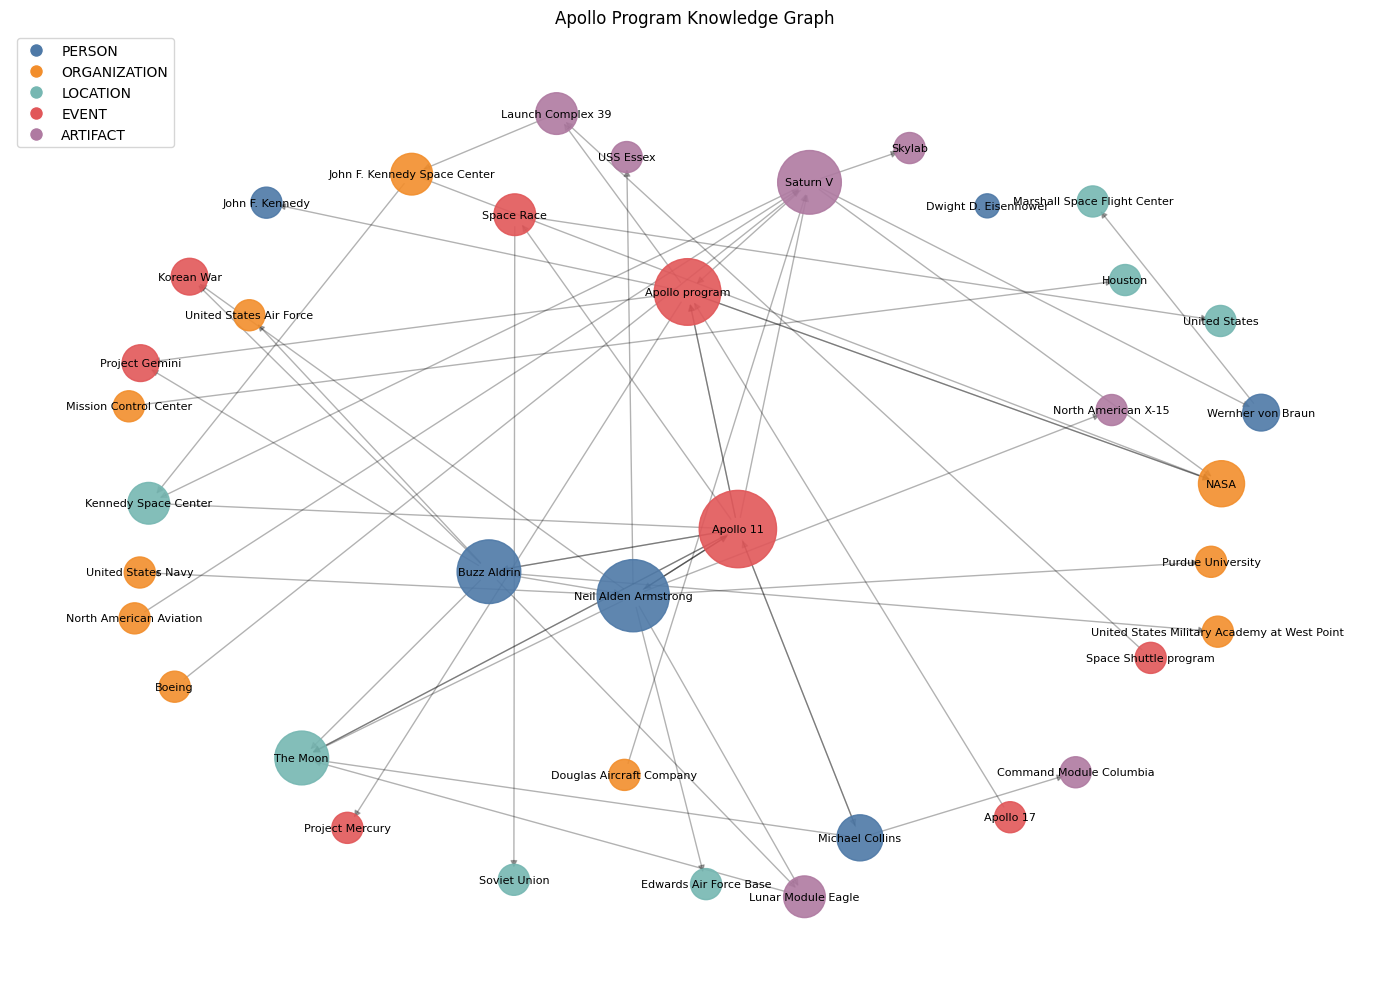

In [10]:
COLOR = {
    "PERSON": "#4e79a7",
    "ORGANIZATION": "#f28e2c",
    "LOCATION": "#76b7b2",
    "EVENT": "#e15759",
    "ARTIFACT": "#af7aa1",
}

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
node_sizes = [300 + 200 * G.degree(n) for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
    for t, c in COLOR.items()
    if any(G.nodes[n]["type"] == t for n in G.nodes)
]
plt.legend(handles=handles, loc="upper left")
plt.title("Apollo Program Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

## Entity summarization

Each node currently carries only the one-line description from whichever document mentioned it first. For the hub nodes — the ones that show up in many documents — we can do much better: pool every mention, add the graph neighborhood as context, and have Claude synthesize a proper profile.

This is the step that turns a graph of labels into a graph of knowledge. The summaries become the node content you surface in search results or feed to downstream QA.

In [11]:
summarize_tool = {
    "name": "summarize_entity",
    "description": "Produce a consolidated profile for a knowledge-graph entity.",
    "input_schema": {
        "type": "object",
        "properties": {
            "summary": {
                "type": "string",
                "description": "2-3 paragraph factual summary synthesized from the source excerpts. Resolve any contradictions by preferring the most specific claim.",
            },
            "key_facts": {
                "type": "array",
                "items": {"type": "string"},
                "description": "3-5 atomic facts, each traceable to the sources.",
            },
            "time_range": {
                "type": "object",
                "properties": {
                    "start": {"type": "string", "description": "YYYY or YYYY-MM, or 'unknown'"},
                    "end": {"type": "string", "description": "YYYY or YYYY-MM, or 'ongoing'"},
                },
                "required": ["start", "end"],
            },
        },
        "required": ["summary", "key_facts", "time_range"],
    },
}

SUMMARIZE_PROMPT = """Generate a knowledge-graph profile for this entity.

Entity: {name} ({etype})

Source excerpts mentioning this entity:
{excerpts}

Known relations in the graph:
{relations}

Synthesize across all sources. Do not invent facts not supported by the excerpts."""


def summarize_entity(name: str) -> dict:
    docs_with_entity = G.nodes[name]["source_docs"]
    excerpts = "\n\n".join(
        f"[{d['title']}]\n{d['text']}" for d in documents if d["title"] in docs_with_entity
    )
    relations = (
        "\n".join(
            f"- {name} --{d['predicate']}--> {tgt}" for _, tgt, d in G.out_edges(name, data=True)
        )
        + "\n"
        + "\n".join(
            f"- {src} --{d['predicate']}--> {name}" for src, _, d in G.in_edges(name, data=True)
        )
    )

    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=1500,
        tools=[summarize_tool],
        tool_choice={"type": "tool", "name": "summarize_entity"},
        messages=[
            {
                "role": "user",
                "content": SUMMARIZE_PROMPT.format(
                    name=name, etype=G.nodes[name]["type"], excerpts=excerpts, relations=relations
                ),
            }
        ],
    )
    return next(b.input for b in response.content if b.type == "tool_use")

In [12]:
hub_nodes = [n for n, _ in sorted(G.degree(), key=lambda x: -x[1])[:3]]

for node in hub_nodes:
    profile = summarize_entity(node)
    G.nodes[node]["profile"] = profile
    print(f"═══ {node} ═══")
    print(profile["summary"])
    print(f"\nTime range: {profile['time_range']['start']} – {profile['time_range']['end']}")
    print("Key facts:")
    for fact in profile["key_facts"]:
        print(f"  • {fact}")
    print()

═══ Apollo 11 ═══
Apollo 11 was the American spaceflight mission that first landed humans on the Moon, occurring July 16–24, 1969. It was the fifth crewed mission of NASA's Apollo program and represented the culmination of the Space Race — a geopolitical competition between the United States and the Soviet Union rooted in Cold War rivalry. The mission fulfilled President John F. Kennedy's national goal, declared before Congress on May 25, 1961, of "landing a man on the Moon and returning him safely to the Earth."

The crew consisted of Commander Neil Armstrong, Command Module Pilot Michael Collins, and Lunar Module Pilot Edwin "Buzz" Aldrin, all on their second and final spaceflights. The spacecraft launched atop a Saturn V rocket from Kennedy Space Center in Florida on July 16, 1969 at 13:32 UTC. After a three-day transit, Armstrong and Aldrin descended to the lunar surface aboard the Lunar Module Eagle, landing in the Sea of Tranquility on July 20 at 20:17 UTC, while Collins remained

═══ Neil Alden Armstrong ═══
Neil Alden Armstrong (August 5, 1930 – August 25, 2012) was an American astronaut, aeronautical engineer, naval aviator, test pilot, and university professor, best known as the first human to walk on the Moon. Born and raised near Wapakoneta, Ohio, he studied aeronautical engineering at Purdue University under the United States Navy's Holloway Plan, becoming a midshipman in 1949 and a naval aviator in 1950. He flew combat missions during the Korean War aboard a Grumman F9F Panther from the aircraft carrier USS Essex, before completing his bachelor's degree and transitioning to a career as a test pilot at the NACA High-Speed Flight Station at Edwards Air Force Base in California, where he flew the North American X-15 seven times and served as project pilot on Century Series fighters.

Armstrong was selected as an astronaut and went on to command the Apollo 11 mission (July 16–24, 1969), NASA's fifth crewed Apollo mission and the first to land humans on the M

═══ Apollo program ═══
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led and conducted by NASA, designed to land humans on the Moon and return them safely to Earth. Conceived in 1960 during the presidency of Dwight D. Eisenhower as a three-person spacecraft program — and building upon the foundations of Project Mercury and Project Gemini — it was formally dedicated to President John F. Kennedy's national goal, declared before the U.S. Congress on May 25, 1961, to land a man on the Moon by the end of the 1960s. All missions launched from Kennedy Space Center's Launch Complex 39 in Florida, and the program's primary launch vehicle was the Saturn V, a three-stage super heavy-lift rocket developed under the direction of Wernher von Braun at the Marshall Space Flight Center.

Kennedy's goal was achieved on July 20, 1969, when Apollo 11 astronauts Neil Armstrong and Buzz Aldrin landed their Lunar Module in the Sea of Tranquility, with Armst

## Querying the graph

The payoff of building a knowledge graph is multi-hop reasoning: answering questions that require chaining facts that never co-occur in a single document. "Which locations are connected to people who flew on Apollo 11?" needs the extractor to have found person→mission edges in one document and person→location edges in another, then the resolver to have unified the person nodes so those edges actually meet.

We serialize a relevant subgraph as triples and let Claude reason over it. For comparison, we first ask the same question with no graph context.

In [13]:
def serialize_subgraph(center: str, hops: int = 2) -> str:
    nodes = {center}
    for _ in range(hops):
        nodes |= {nbr for n in nodes for nbr in G.successors(n)}
        nodes |= {nbr for n in nodes for nbr in G.predecessors(n)}
    sub = G.subgraph(nodes)
    lines = [f"({s}) --[{d['predicate']}]--> ({t})" for s, t, d in sub.edges(data=True)]
    return "\n".join(sorted(set(lines)))


def ask(question: str, graph_context: str | None = None) -> str:
    if graph_context:
        prompt = f"""Answer using only the knowledge graph below. Cite the specific edges that support your answer.

<graph>
{graph_context}
</graph>

Question: {question}"""
    else:
        prompt = question
    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=500,
        messages=[{"role": "user", "content": prompt}],
    )
    return response.content[0].text

In [14]:
apollo_11 = next((n for n in G.nodes if "Apollo 11" in n), hub_nodes[0])
subgraph = serialize_subgraph(apollo_11, hops=2)

question = "Which locations are connected to people who were part of Apollo 11, and how?"

print("WITHOUT graph context:")
print(ask(question))
print("\n" + "─" * 60 + "\n")
print("WITH graph context:")
print(ask(question, subgraph))

WITHOUT graph context:


# Locations Connected to Apollo 11 People

Here's a breakdown of key locations tied to the three Apollo 11 astronauts and their connections:

---

## Neil Armstrong

| Location | Connection |
|----------|------------|
| Wapakoneta, Ohio | Birthplace and hometown |
| Purdue University, Indiana | Earned his bachelor's degree in aeronautical engineering |
| Edwards Air Force Base, California | Served as a test pilot |
| Houston, Texas | NASA astronaut base (Johnson Space Center) |
| Lebanon, Ohio area | Lived on a farm in his later years |

---

## Buzz Aldrin

| Location | Connection |
|----------|------------|
| Montclair, New Jersey | Birthplace |
| West Point, New York | Graduated from the U.S. Military Academy |
| MIT, Massachusetts | Earned his doctorate |
| Houston, Texas | NASA posting |

---

## Michael Collins

| Location | Connection |
|----------|------------|
| Rome, Italy | Birthplace (son of a U.S. Army officer) |
| Washington, D.C. | Grew up there; later directed the Natio

## Locations Connected to Apollo 11 Crew Members

### Neil Alden Armstrong
- **Purdue University** – (Neil Alden Armstrong) --[studied at]--> (Purdue University)
- **Edwards Air Force Base** – (Neil Alden Armstrong) --[worked at]--> (Edwards Air Force Base)
- **USS Essex** – (Neil Alden Armstrong) --[flew from]--> (USS Essex)
- **The Moon** – (Neil Alden Armstrong) --[landed on]--> (The Moon)

### Buzz Aldrin
- **United States Military Academy at West Point** – (Buzz Aldrin) --[graduated from]--> (United States Military Academy at West Point)
- **The Moon** – (Buzz Aldrin) --[landed on]--> (The Moon)

### Michael Collins
- **The Moon** (orbit) – (Michael Collins) --[remained in orbit around]--> (The Moon)

---

## Summary

| Location | Person | Relationship |
|---|---|---|
| Purdue University | Neil Armstrong | Studied at |
| Edwards Air Force Base | Neil Armstrong | Worked at |
| USS Essex | Neil Armstrong | Flew from |
| West Point | Buzz Aldrin | Graduated from |
| The Moon | Armstr

The ungrounded answer draws on Claude's pretraining and may be correct — Apollo 11 is famous. But the grounded answer is **traceable**: every claim cites an edge we extracted from a specific document. On a private corpus where Claude has no prior knowledge, only the grounded answer works at all.

## Evaluation

Knowledge graph quality is measured with precision and recall against a gold set. We ship a small hand-labeled set in `data/sample_triples.json` covering two of the articles. Entity matches are case-insensitive; relation matches require both endpoints to resolve to the same canonical form (predicate wording is ignored since "commanded" and "was commander of" are equivalent).

Run the full evaluation with:

```bash
python evaluation/eval_extraction.py
```

Here we run the entity-level check inline:

In [15]:
with open("data/sample_triples.json") as f:
    gold = json.load(f)


def prf(predicted: set, gold: set) -> tuple[float, float, float]:
    tp = len(predicted & gold)
    p = tp / len(predicted) if predicted else 0.0
    r = tp / len(gold) if gold else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f1


for doc_title, labels in gold.items():
    predicted = {e["name"].lower() for e in raw_entities if e["source_doc"] == doc_title}
    gold_names = {e["name"].lower() for e in labels["entities"]}
    p, r, f1 = prf(predicted, gold_names)
    print(f"{doc_title:<20}  P={p:.2f}  R={r:.2f}  F1={f1:.2f}")
    missed = gold_names - predicted
    if missed:
        print(f"  missed: {', '.join(sorted(missed))}")

Apollo 11             P=0.67  R=0.91  F1=0.77
  missed: columbia
Neil Armstrong        P=0.56  R=0.62  F1=0.59
  missed: gemini 8, nasa, neil armstrong


## Scaling up

This notebook processed six documents in memory. Production knowledge graphs are built from thousands. A few notes on scaling:

**Extraction cost.** Haiku is cheap enough to run on large corpora, but [prompt caching](https://docs.claude.com/en/docs/build-with-claude/prompt-caching) cuts costs further when your extraction schema and instructions stay fixed — cache the tool definition and prompt preamble, pay full price only for the document text. The [Message Batches API](https://docs.claude.com/en/docs/build-with-claude/batch-processing) gives 50% off for jobs that can wait up to 24 hours.

**Entity resolution at scale.** Feeding ten thousand PERSON entities to Claude in one prompt doesn't work. Block first: group candidates by cheap signals (same last name, overlapping tokens, embedding similarity) so Claude only arbitrates within small blocks. The resolution prompt above works unchanged on blocks of 50–100.

**Incremental updates.** When a new document arrives, extract its entities, resolve them against the existing canonical set (not against each other), and add only the new edges. Re-summarize an entity only when its source-document set changes materially.

**Storage.** NetworkX is fine to a few hundred thousand edges. Beyond that, the schema maps directly onto a property graph (Neo4j, Neptune) or three Postgres tables: `entities(id, name, type, summary)`, `relations(source_id, target_id, predicate)`, `aliases(entity_id, alias)`. The extraction and resolution code doesn't change — only the persistence layer does.